# Clustering in Scanpy

In [3]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [4]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.3] # This takes a while per res
batch_col = 'plate' # Should we set to plate and sample??
run_genes_in_smpl_filter = True

2025-01-21 10:17:24,223 - INFO - Plate variable detected: plate1
2025-01-21 10:17:24,225 - INFO - Processing plate: plate1



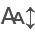

2025-01-21 10:17:24,262 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-21 10:17:24,262 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-01-21 10:17:24,263 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-21 10:17:24,263 - INFO - Scanpy directory exists: True
2025-01-21 10:17:24,264 - INFO - Sheets directory: /Users/darren/Desktop/eQTL_study_2025/resources/sheets/
2025-01-21 10:17:24,265 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-21 10:17:24,265 - INFO - Loading data ...


Processing 2 plate(s), no downsampling applied.
Loading plate 1 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate1.h5ad ...
Plate 1 dimensions: (1763, 23742)
Plate 1 matrix dimensions: (1763, 23742)
Loading plate 2 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate2.h5ad ...
Plate 2 dimensions: (3462, 33088)
Plate 2 matrix dimensions: (3462, 33088)
Common genes across all plates: 23631
Merging plates ...
AnnData object with n_obs × n_vars = 5225 × 23631
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', '

(5225, 23631)

In [5]:
# Initialize the environment and get all paths and logger
logger, root_dir, sheets_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")
adata = load_and_dwnsmpl_data(None, scanpy_dir + 'adata_qc_plate1.h5ad', scanpy_dir + 'adata_qc_plate2.h5ad')
adata.shape

# Optional filter based on genes expressed by sample

In [6]:
# Retain genes with at least min_reads in at least min_samples in the dataset
if run_genes_in_smpl_filter is True:
    filter_genes_by_read_count(adata, min_reads=10, min_samples=100, inplace=True)
    print(f"Filtered genes: {adata.n_vars} remain.")

Filtered genes: 0 remain.


# Initial cell counts

In [7]:
# Cell counts by sample
print(f"Number of samples: {adata.obs['sample'].nunique()}")
adata.obs['sample'].value_counts()

Number of samples: 150


sample
16024       143
1118        116
14706       105
13910        90
15658        75
           ... 
19043        11
12971_FC     10
16972        10
17109         9
14521         8
Name: count, Length: 150, dtype: int64

In [8]:
# Cell counts by sublibrary
adata.obs['sublibrary'] = [x[1] for x in adata.obs.index.str.split('__s')] 
adata.obs['sublibrary'].value_counts()

sublibrary
1     390
3     374
6     369
2     361
10    342
12    332
7     330
5     328
15    325
8     323
4     319
14    313
11    312
9     310
13    304
16    193
Name: count, dtype: int64

In [9]:
#Cell counts by plate
adata.obs['plate'].value_counts()


plate
plate2    3462
plate1    1763
Name: count, dtype: int64

In [10]:
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                   
plate1_57_30_71__s6   13117    hg38        1043        1452         2370   
plate1_44_34_46__s14  17048    hg38        3948        9928        23585   
plate1_49_62_02__s2   11511    hg38        1462        2126         6108   
plate1_50_83_12__s15  15611    hg38        3299        7059        14267   
plate1_46_23_36__s5   18372    hg38        2281        4040         9706   
...                     ...     ...         ...         ...          ...   
plate2_20_04_41__s11  13424    hg38        2394        3978         8115   
plate2_54_80_45__s13  15265    hg38        2874        5373        12698   
plate2_52_24_03__s16  15249    hg38         459         582         1518   
plate2_12_79_82__s14   1102    hg38        3249        7926        23665   
plate2_26_44_77__s14  13910    hg38        1082        1497         4001   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate1_57_30_71__s6       1               1043                 6.950815   
plate1_44_34_46__s14      4               3948                 8.281218   
plate1_49_62_02__s2       3               1462                 7.288244   
plate1_50_83_12__s15      0               3299                 8.101678   
plate1_46_23_36__s5       6               2281                 7.732808   
...                     ...                ...                      ...   
plate2_20_04_41__s11     12               2394                 7.781139   
plate2_54_80_45__s13      0               2874                 7.963808   
plate2_52_24_03__s16      1                459                 6.131226   
plate2_12_79_82__s14      0               3249                 8.086410   
plate2_26_44_77__s14      5               1082                 6.987490   

                      total_counts  log1p_total_counts  ...  total_counts_hb  \
bc_wells                                                ...                    
plate1_57_30_71__s6    3954.378520            8.282832  ...         0.000000   
plate1_44_34_46__s14   9063.124751            9.112080  ...         0.000000   
plate1_49_62_02__s2    5375.231639            8.589743  ...         0.000000   
plate1_50_83_12__s15   7547.901036            8.929157  ...         0.000000   
plate1_46_23_36__s5    6528.936762            8.784153  ...         0.000000   
...                            ...                 ...  ...              ...   
plate2_20_04_41__s11   7207.586196            8.883028  ...         0.000000   
plate2_54_80_45__s13   7706.775436            8.949985  ...         0.000000   
plate2_52_24_03__s16   2080.338320            7.640766  ...         0.000000   
plate2_12_79_82__s14   7708.189648            8.950168  ...         9.157249   
plate2_26_44_77__s14   4262.092720            8.357750  ...         0.000000   

                      log1p_total_counts_hb  pct_counts_hb  n_genes  \
bc_wells                                                              
plate1_57_30_71__s6                0.000000       0.000000     1031   
plate1_44_34_46__s14               0.000000       0.000000     3745   
plate1_49_62_02__s2                0.000000       0.000000     1418   
plate1_50_83_12__s15               0.000000       0.000000     3193   
plate1_46_23_36__s5                0.000000       0.000000     2207   
...                                     ...            ...      ...   
plate2_20_04_41__s11               0.000000       0.000000     2394   
plate2_54_80_45__s13               0.000000       0.000000     2874   
plate2_52_24_03__s16               0.000000       0.000000      459   
plate2_12_79_82__s14               2.318188       0.118799     3249   
plate2_26_44_77__s14               0.000000       0.000000     1082   

                         n_counts  doublet_score  predicted_doublet  \
bc_wells            

In [11]:
# Normalise
logger.info("Normalising ...")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

2025-01-21 10:17:25,964 - INFO - Normalising ...


normalizing counts per cell
    finished (0:00:00)


ValueError: Found array with 0 feature(s) (shape=(5225, 0)) while a minimum of 1 is required.

2025-01-20 15:36:03,186 - INFO - Detecting variable genes ...


extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
    ... clipping at max_value 10


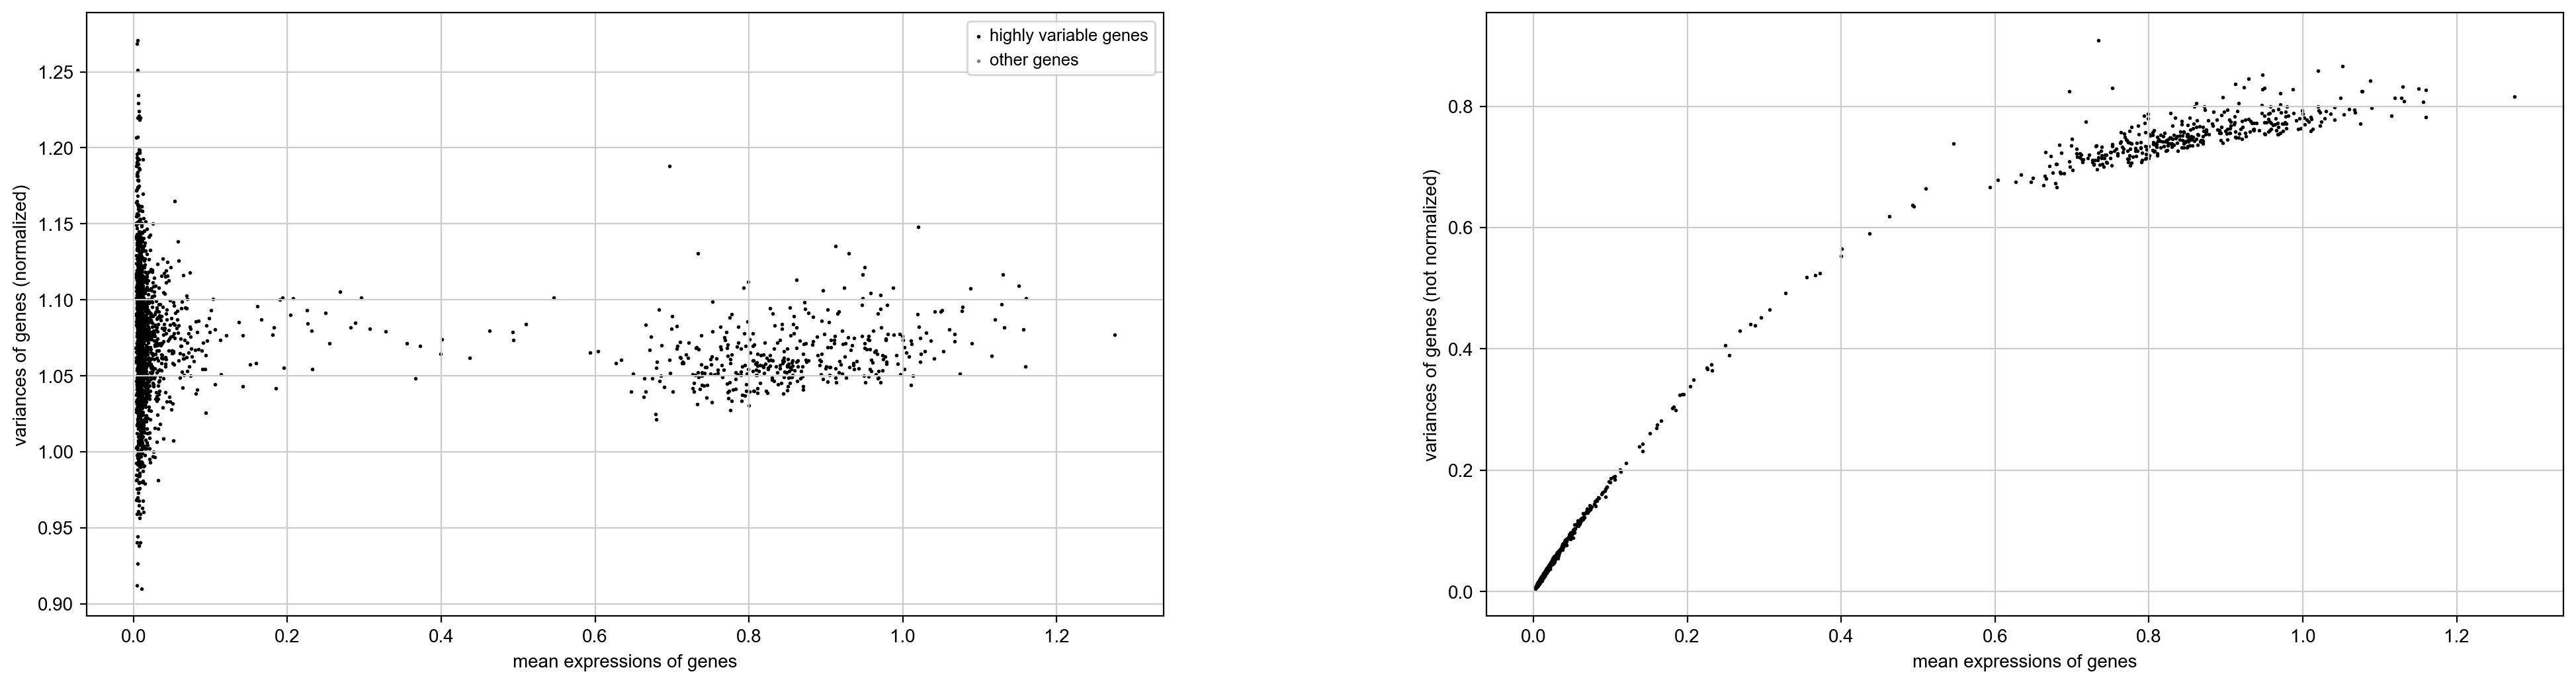

In [189]:
# Get highly variable genes
logger.info("Detecting variable genes ...")
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key=batch_col)
# This saves the original set of genes 
adata.raw = adata

adata = adata[:,adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.pl.highly_variable_genes(adata)

hvg_genes = sorted(adata.var_names[adata.var['highly_variable']])
with open(scanpy_dir + "highly_variable_genes.txt", "w") as f:
    for gene in hvg_genes:
        f.write(f"{gene}\n")



2025-01-20 15:36:04,138 - INFO - PCA ...


computing PCA
    with n_comps=50
    finished (0:00:03)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])


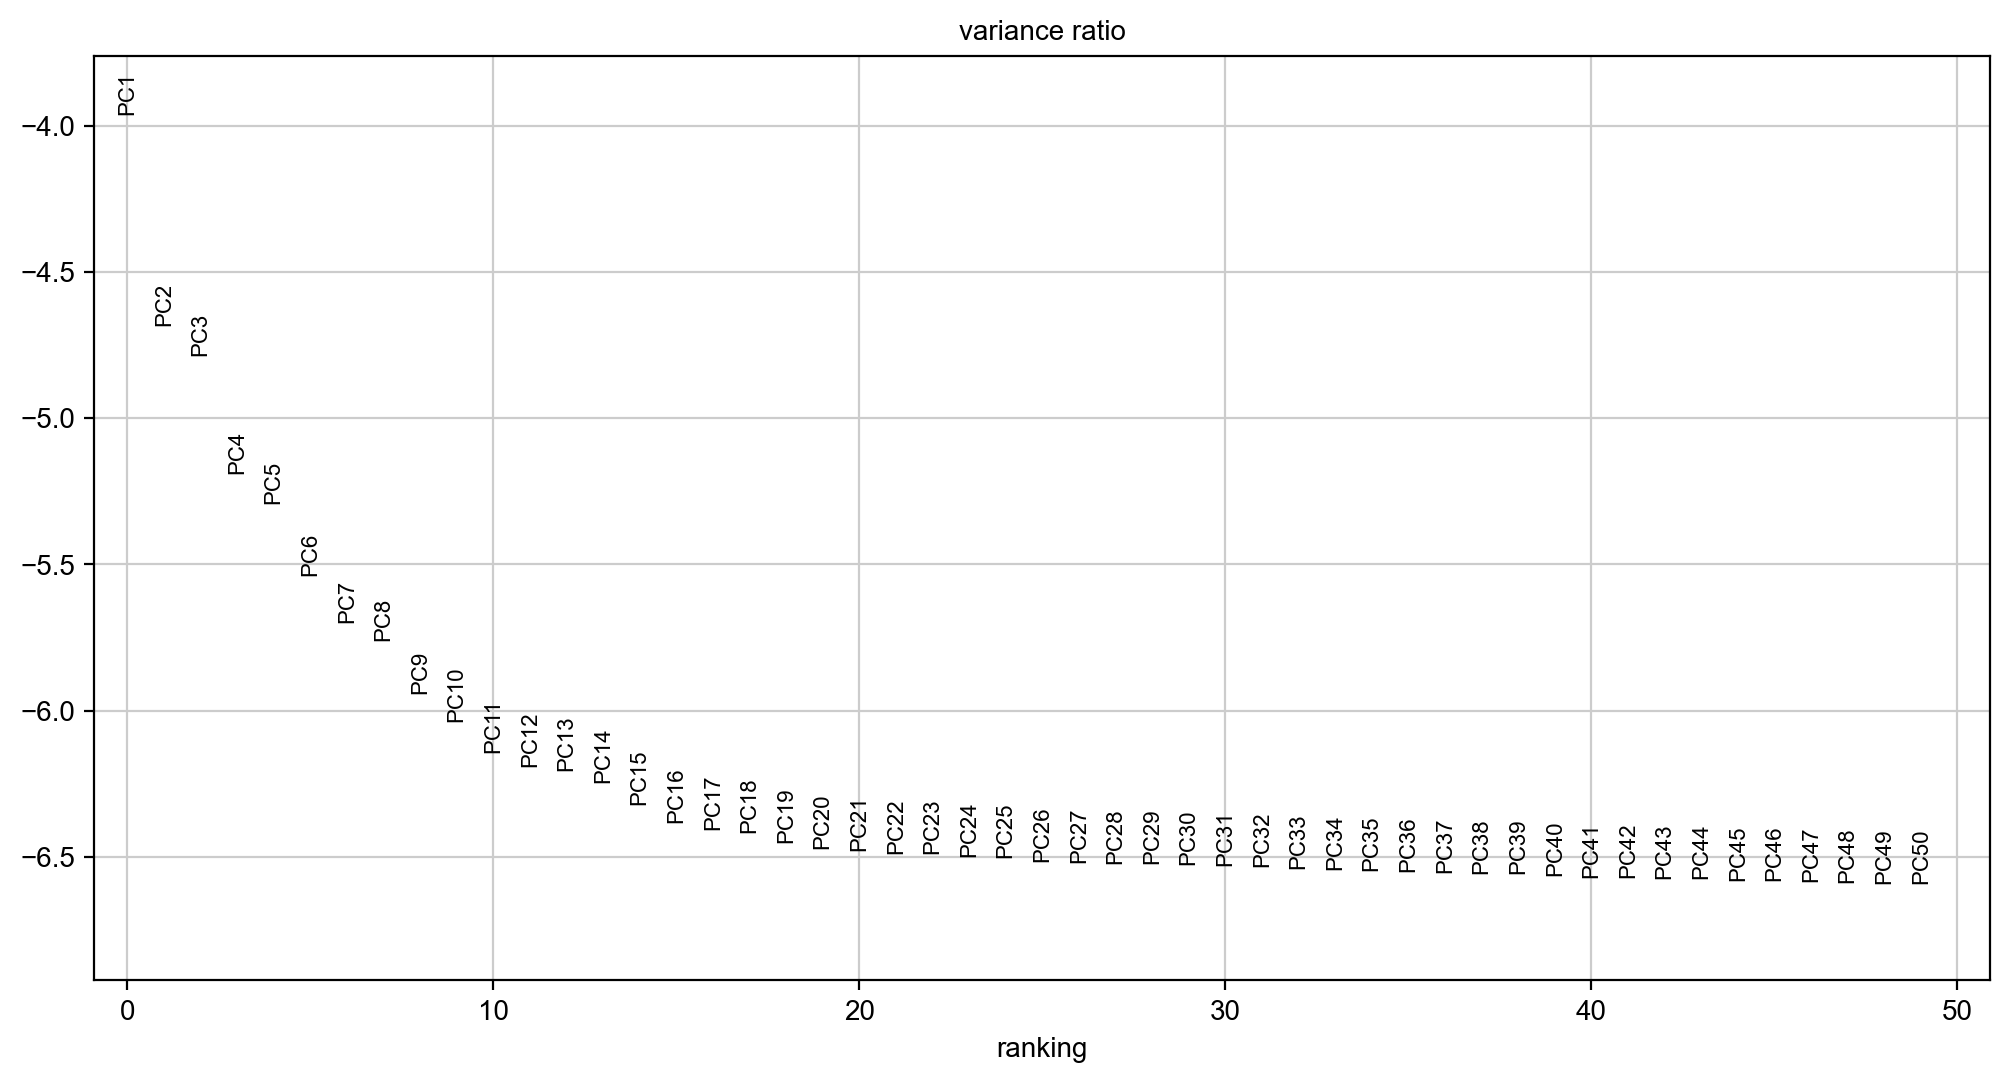

In [190]:
# PCA
logger.info("PCA ...")
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='') # scanpy generates the filename automatically

In [191]:
# Plotting
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                   
plate1_57_30_71__s6   13117    hg38        1043        1452         2370   
plate1_44_34_46__s14  17048    hg38        3948        9928        23585   
plate1_49_62_02__s2   11511    hg38        1462        2126         6108   
plate1_50_83_12__s15  15611    hg38        3299        7059        14267   
plate1_46_23_36__s5   18372    hg38        2281        4040         9706   
...                     ...     ...         ...         ...          ...   
plate2_20_04_41__s11  13424    hg38        2394        3978         8115   
plate2_54_80_45__s13  15265    hg38        2874        5373        12698   
plate2_52_24_03__s16  15249    hg38         459         582         1518   
plate2_12_79_82__s14   1102    hg38        3249        7926        23665   
plate2_26_44_77__s14  13910    hg38        1082        1497         4001   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate1_57_30_71__s6       1               1043                 6.950815   
plate1_44_34_46__s14      4               3948                 8.281218   
plate1_49_62_02__s2       3               1462                 7.288244   
plate1_50_83_12__s15      0               3299                 8.101678   
plate1_46_23_36__s5       6               2281                 7.732808   
...                     ...                ...                      ...   
plate2_20_04_41__s11     12               2394                 7.781139   
plate2_54_80_45__s13      0               2874                 7.963808   
plate2_52_24_03__s16      1                459                 6.131226   
plate2_12_79_82__s14      0               3249                 8.086410   
plate2_26_44_77__s14      5               1082                 6.987490   

                      total_counts  log1p_total_counts  ...  total_counts_hb  \
bc_wells                                                ...                    
plate1_57_30_71__s6    3954.378520            8.282832  ...         0.000000   
plate1_44_34_46__s14   9063.124751            9.112080  ...         0.000000   
plate1_49_62_02__s2    5375.231639            8.589743  ...         0.000000   
plate1_50_83_12__s15   7547.901036            8.929157  ...         0.000000   
plate1_46_23_36__s5    6528.936762            8.784153  ...         0.000000   
...                            ...                 ...  ...              ...   
plate2_20_04_41__s11   7207.586196            8.883028  ...         0.000000   
plate2_54_80_45__s13   7706.775436            8.949985  ...         0.000000   
plate2_52_24_03__s16   2080.338320            7.640766  ...         0.000000   
plate2_12_79_82__s14   7708.189648            8.950168  ...         9.157249   
plate2_26_44_77__s14   4262.092720            8.357750  ...         0.000000   

                      log1p_total_counts_hb  pct_counts_hb  n_genes  \
bc_wells                                                              
plate1_57_30_71__s6                0.000000       0.000000     1031   
plate1_44_34_46__s14               0.000000       0.000000     3745   
plate1_49_62_02__s2                0.000000       0.000000     1418   
plate1_50_83_12__s15               0.000000       0.000000     3193   
plate1_46_23_36__s5                0.000000       0.000000     2207   
...                                     ...            ...      ...   
plate2_20_04_41__s11               0.000000       0.000000     2394   
plate2_54_80_45__s13               0.000000       0.000000     2874   
plate2_52_24_03__s16               0.000000       0.000000      459   
plate2_12_79_82__s14               2.318188       0.118799     3249   
plate2_26_44_77__s14               0.000000       0.000000     1082   

                         n_counts  doublet_score  predicted_doublet  \
bc_wells            

In [192]:
# UMAP and Clustering
logger.info("Clustering and UMAP ...")
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)

for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')

2025-01-20 15:36:08,799 - INFO - Clustering and UMAP ...


computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 30
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)
running Leiden clustering
    finished: found 8 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:00)


2025-01-20 15:36:15,307 - INFO - Plot UMAP ...
... storing 'plate' as categorical
... storing 'sublibrary' as categorical


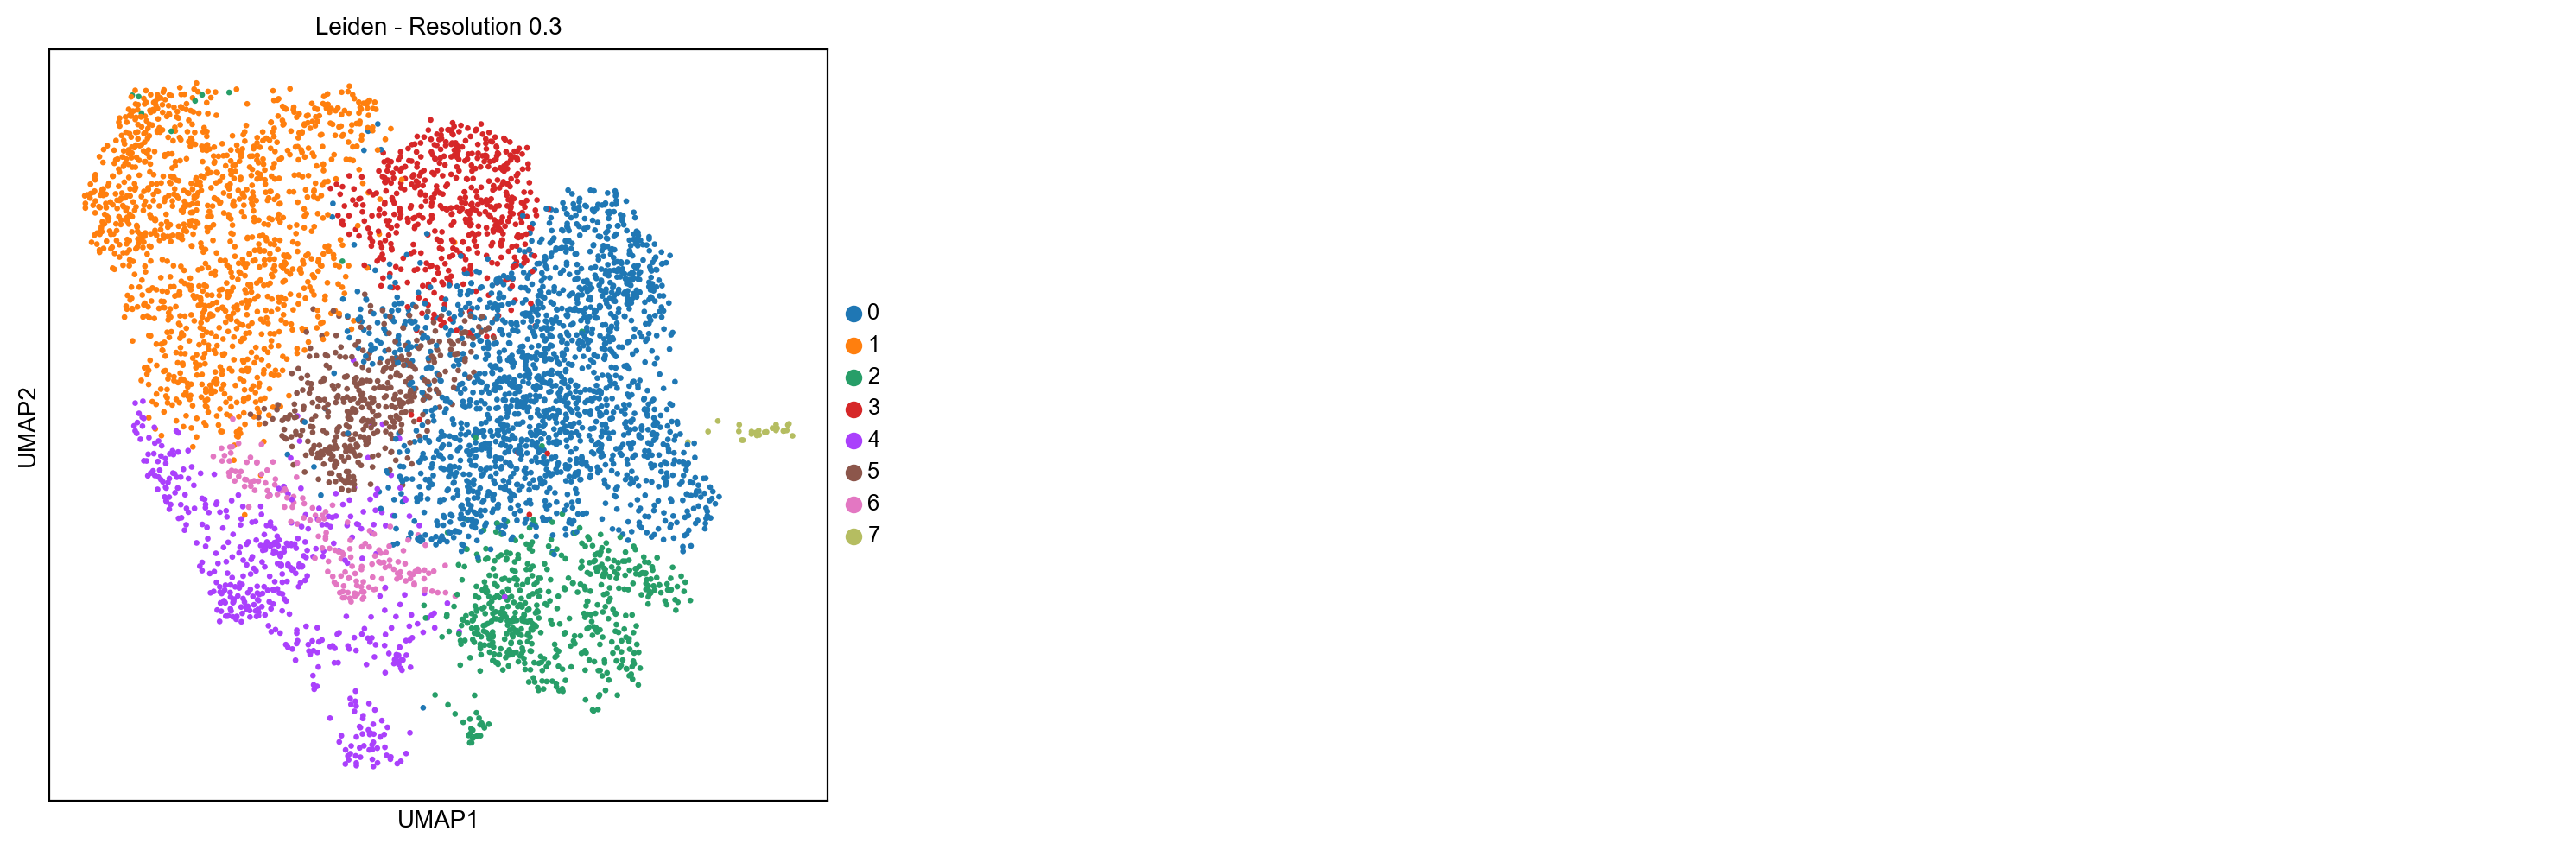

In [193]:
# Helper function
logger.info("Plot UMAP ...")
#create_umap_visualisations(adata, resolutions, leiden_prefix="leiden")

fig = create_umap_visualisations(adata, resolutions, leiden_prefix="leiden", clustering_algorithm="Leiden")
plt.show() 

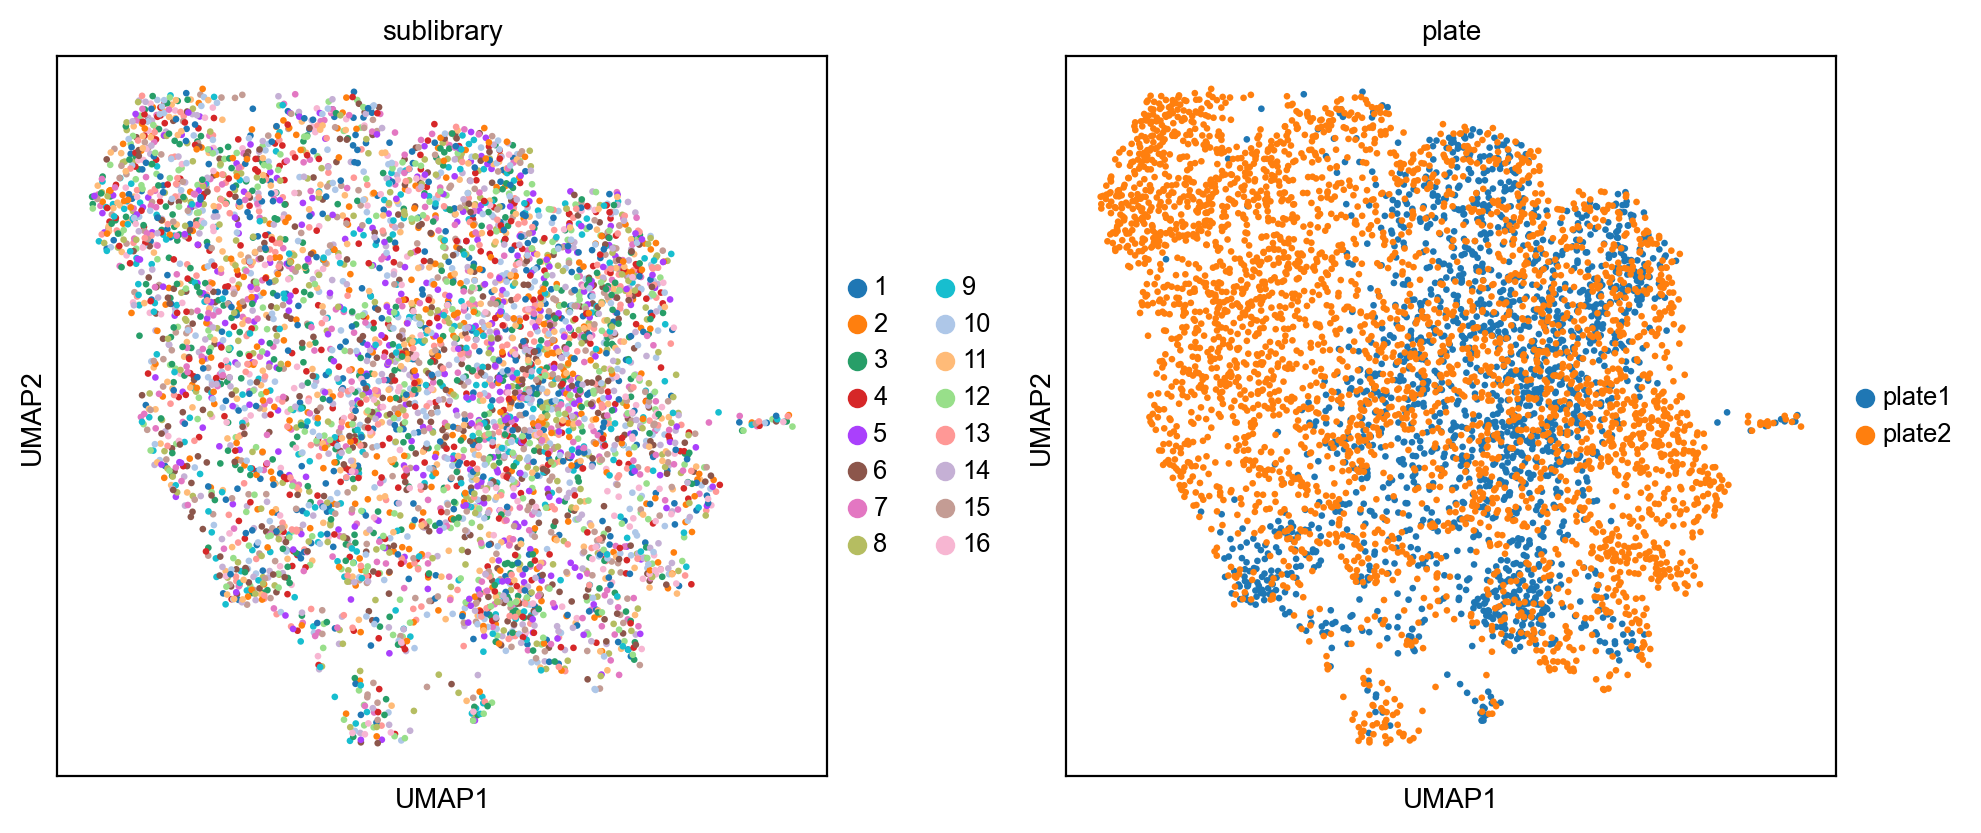

In [194]:
# UMAPs by .obs column
obs_columns = ['sublibrary', 'plate']
plot_umap_grid(adata, obs_columns, grid_size=(2, 2), figsize=(10, 8), save_path=None)

2025-01-20 15:36:16,455 - INFO - Plot Violin 1 ...
2025-01-20 15:36:16,548 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,556 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,558 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,653 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,661 - INFO - Using categorical units 

Genes not found in dataset for gene set general_genes: SST, PVALB, VIP, C1QB, PDGRFA
Generating plots for resolution: 0.3
Plotting gene set general_genes with 22 genes out of 27 provided.


2025-01-20 15:36:16,759 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,767 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,771 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,862 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:16,870 - INFO - Using categorical units to plot a list of strings that are all parsable as 

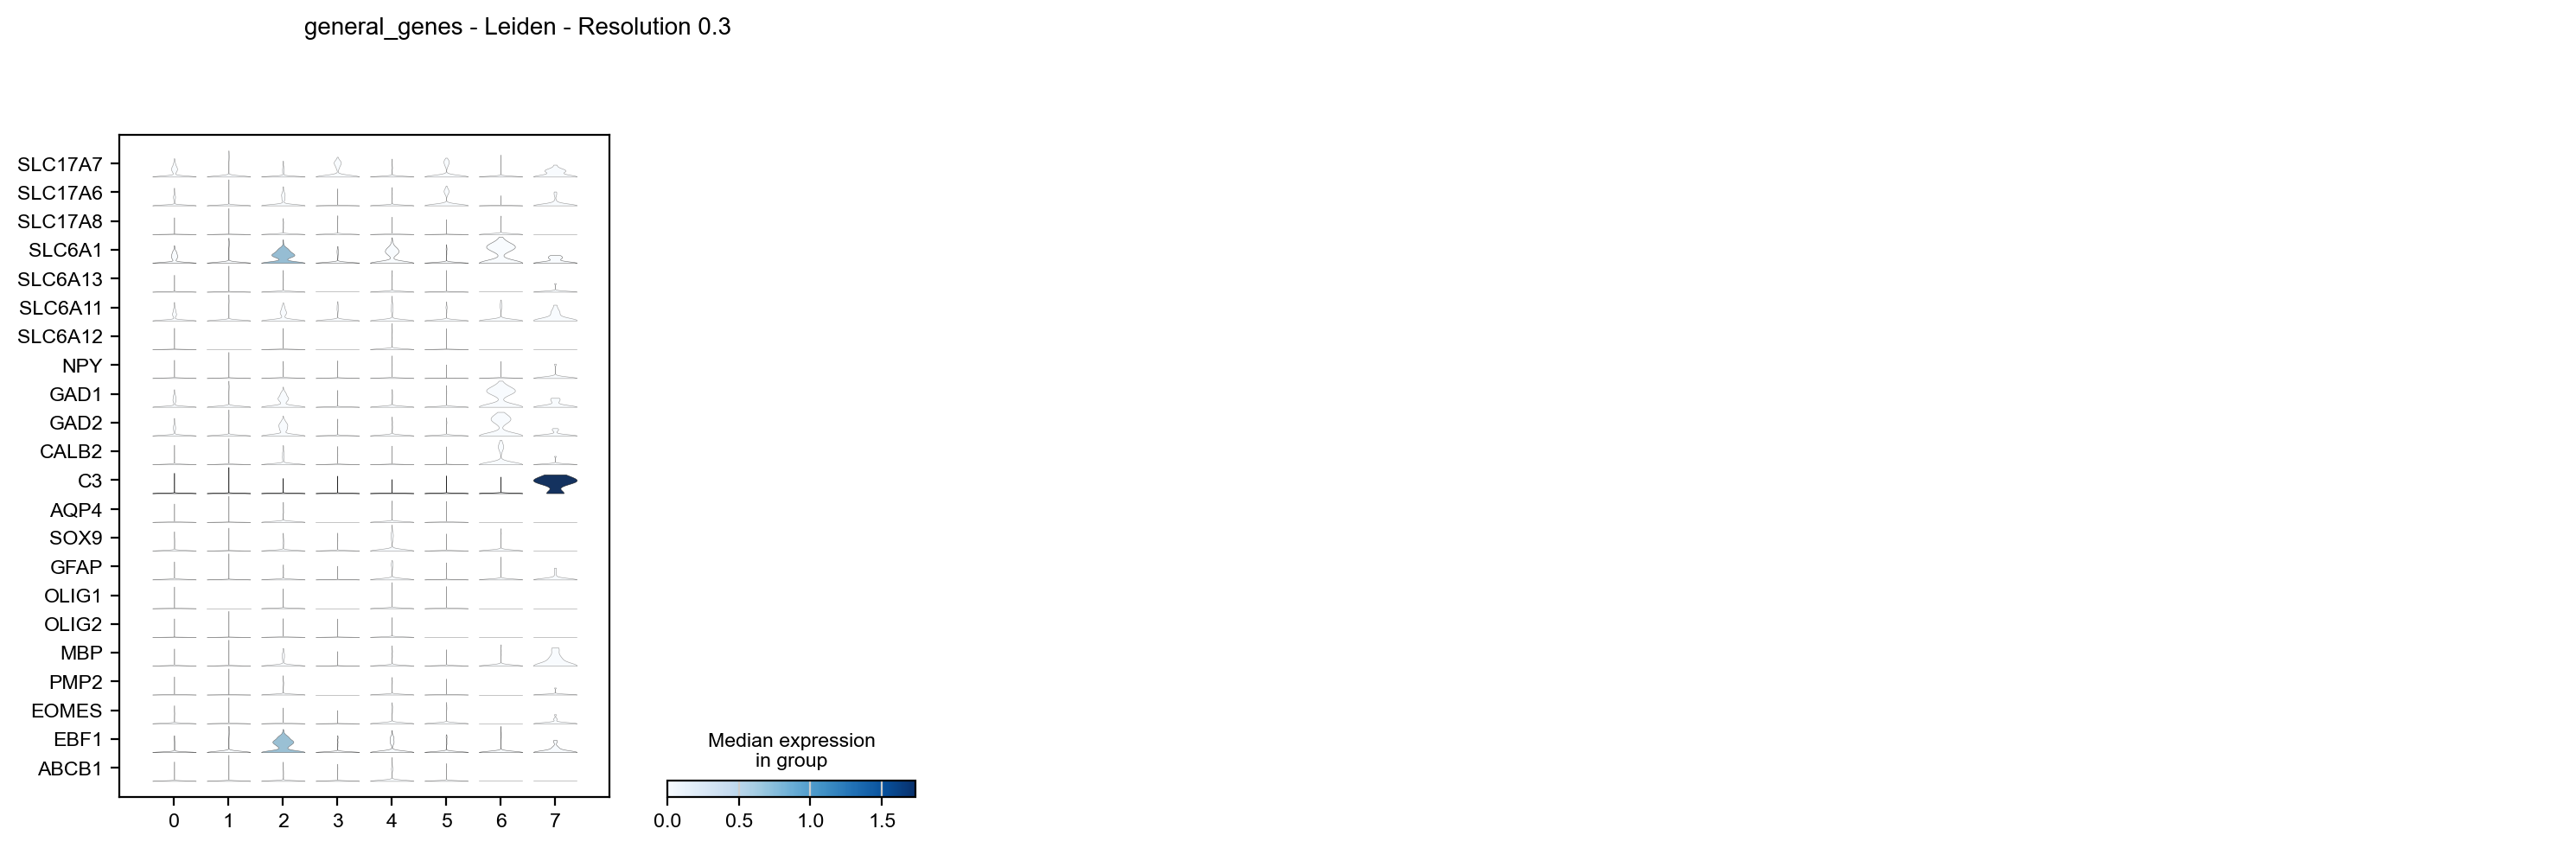

In [195]:
# Violin plots
logger.info("Plot Violin 1 ...")
gene_sets = [
    ("general_genes", general_genes)
]

# Need to get rid of infor warnings and tweak plts
fig, axes = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=resolutions, 
    clustering_algorithm="Leiden")
plt.show()  # Display the figure

2025-01-20 15:36:19,349 - INFO - Plot Violin 2 ...
2025-01-20 15:36:19,444 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:19,451 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:19,453 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Genes not found in dataset for gene set general_genes: SST, PVALB, VIP, C1QB, PDGRFA
Genes not found in dataset for gene set pfc_features: SST
Generating plots for resolution: 0.3
Plotting gene set general_genes with 22 genes out of 27 provided.


2025-01-20 15:36:19,582 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:19,594 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:19,597 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:19,736 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:19,746 - INFO - Using categorical units to plot a list of strings that are all parsable as 

Plotting gene set pfc_features with 14 genes out of 15 provided.


2025-01-20 15:36:22,289 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:22,297 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:22,300 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:22,397 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-20 15:36:22,406 - INFO - Using categorical units to plot a list of strings that are all parsable as 

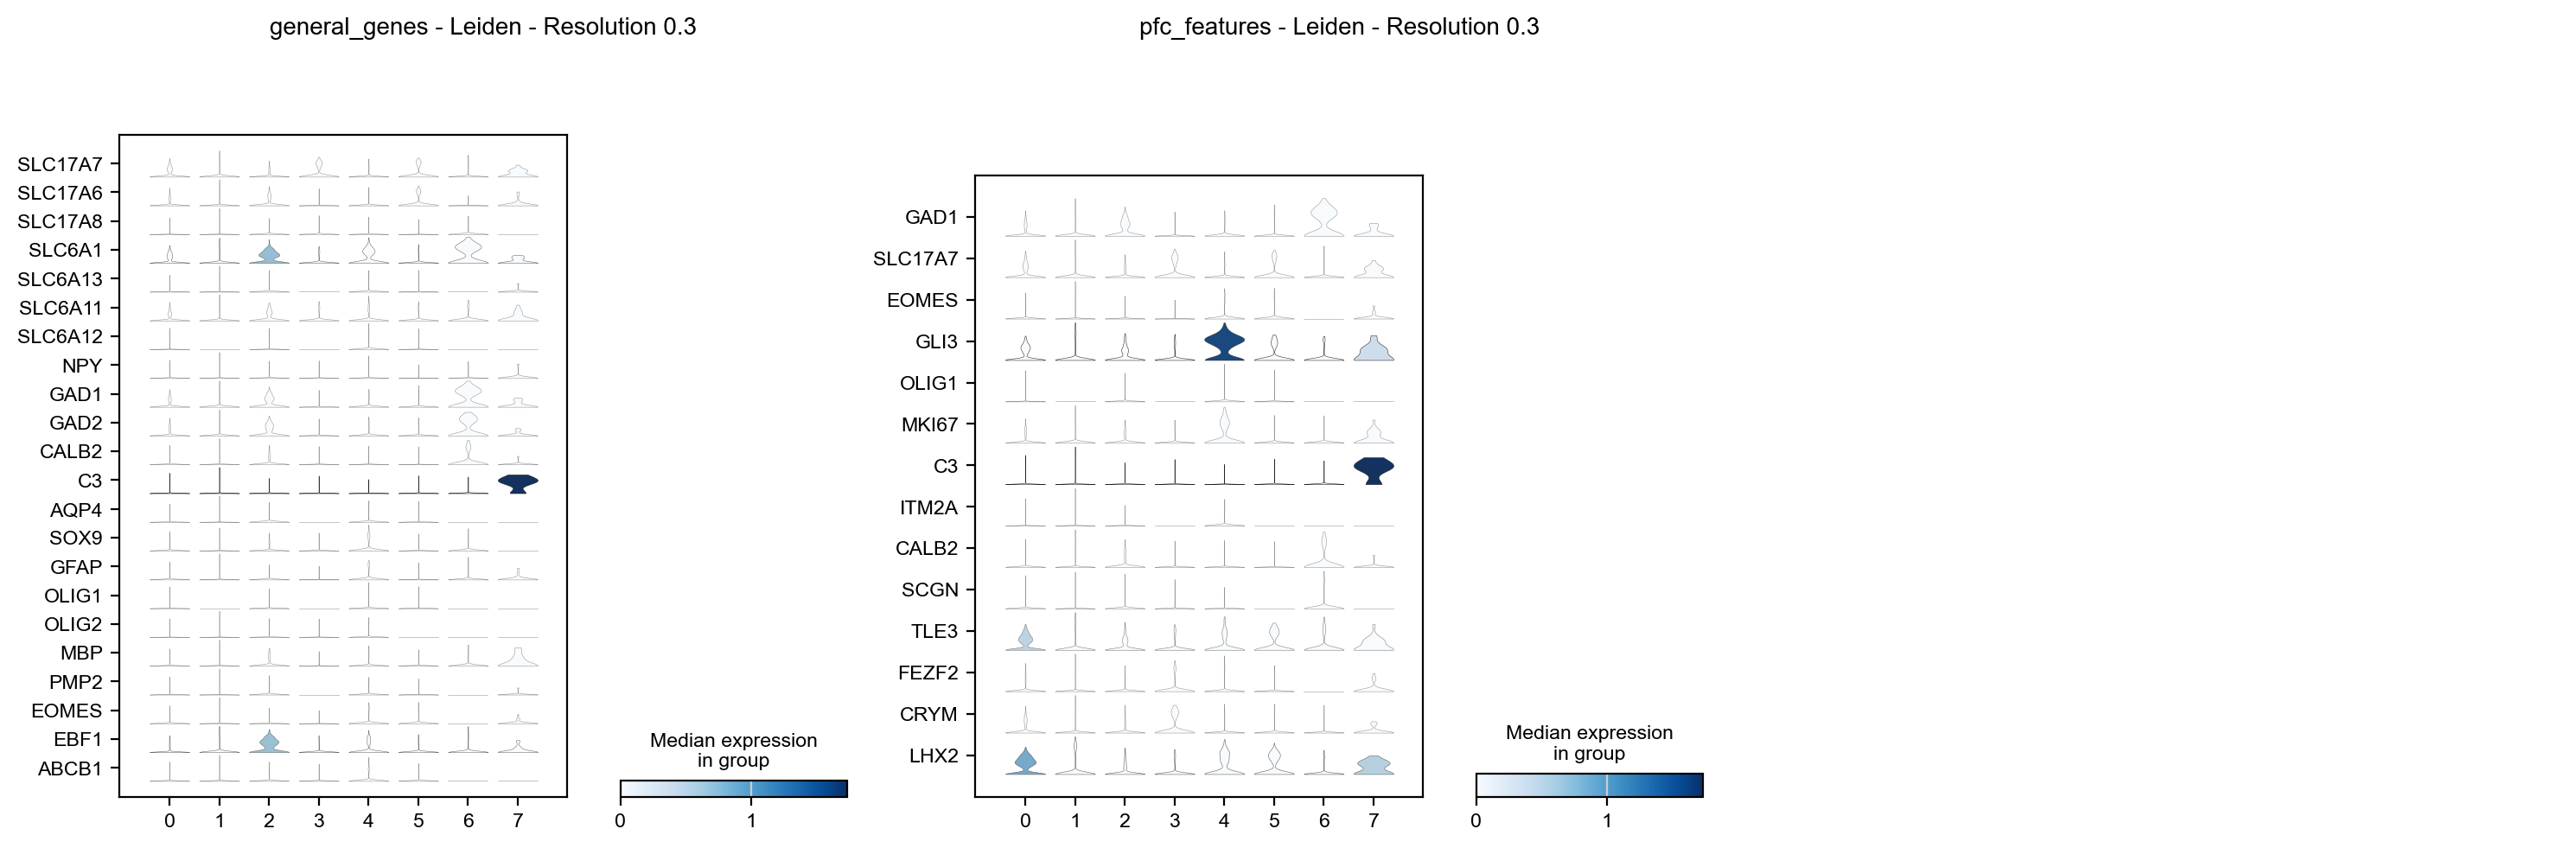

In [196]:
logger.info("Plot Violin 2 ...")
gene_sets = [
    ("general_genes", general_genes),
    ("pfc_features", pfc_features)
]

fig = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=resolutions, 
    clustering_algorithm="Leiden")
plt.show()  # Display the figure

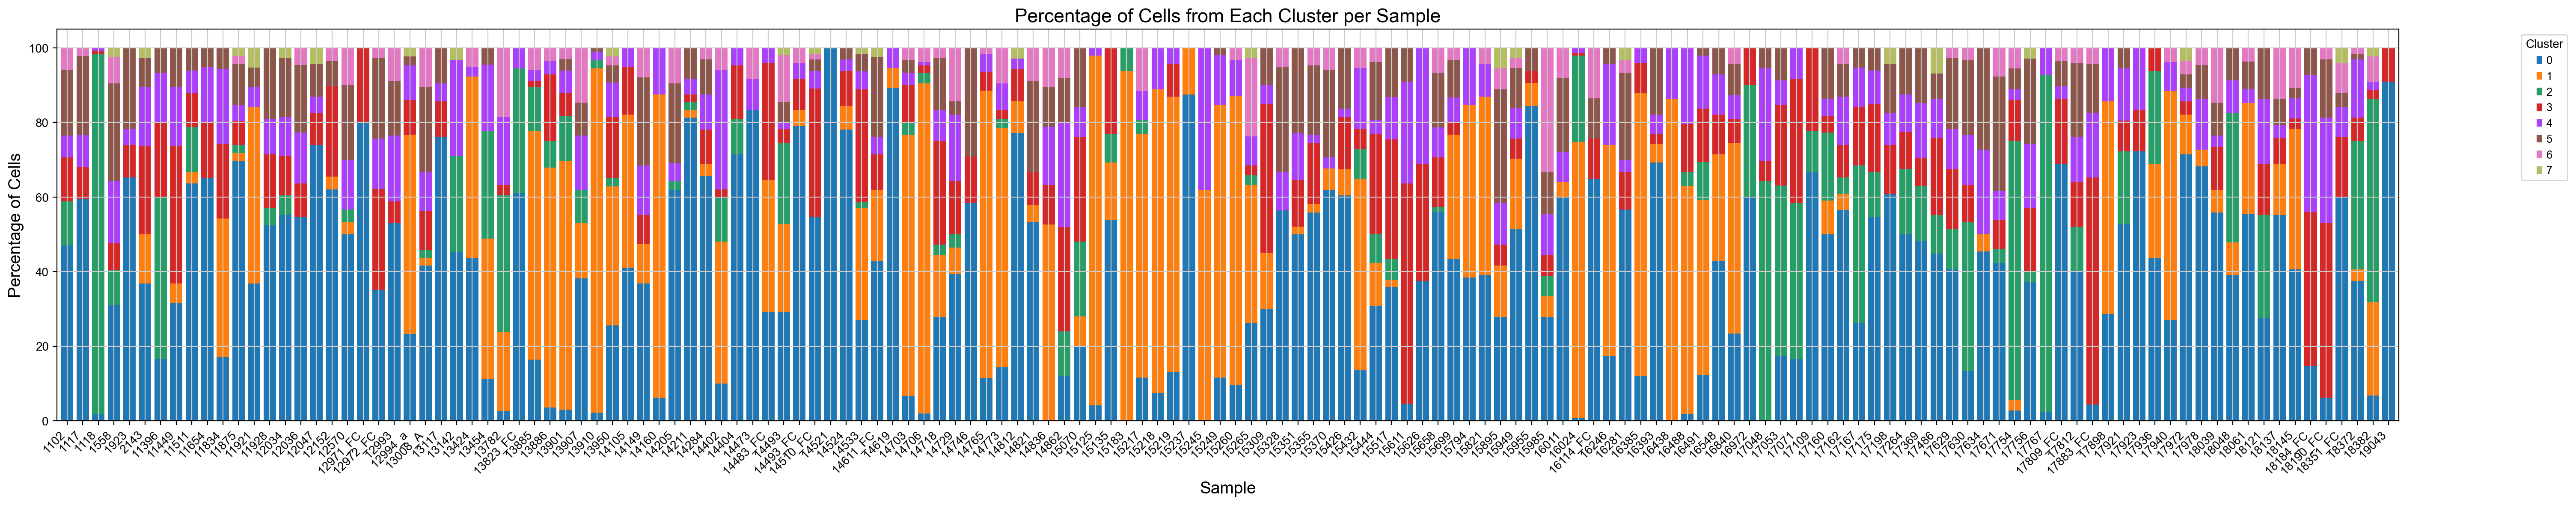

In [197]:
# Plot sample per cluster
# Function saves an excel file with the cell counts per sample per cluster 
# Extract sample and leiden cluster information from the AnnData object
fig = plot_and_save_cluster_percentages(
    adata=adata,
    output_dir = scanpy_dir,
    clustering_param="leiden_0.3"
)
plt.show() 


In [198]:
logger.info("Saving h5ad file ...")
adata.write(scanpy_dir + f'adata_clusters.h5ad')
logger.info("All done.")

2025-01-20 15:36:26,956 - INFO - Saving h5ad file ...
2025-01-20 15:36:27,434 - INFO - All done.
